In [6]:
using Oceananigans
using Oceananigans.Units
using CairoMakie

In [7]:

# load the full 3d dye fields without placing every saved time in memory
dye_on = FieldTimeSeries(
    "amazon_rivers_on_dye_3d.jld2",
    "dye";
    backend = OnDisk()
)

dye_off = FieldTimeSeries(
    "amazon_rivers_off_dye_3d.jld2",
    "dye";
    backend = OnDisk()
)

# recover each grid from its corresponding output file
grid_on = dye_on.grid
grid_off = dye_off.grid

# determine how many snapshots are available in both simulations
Nt = min(length(dye_on.times), length(dye_off.times))

# select the shared portions of the saved time coordinates
times_on = dye_on.times[1:Nt]
times_off = dye_off.times[1:Nt]

# convert the model times from seconds to days for plotting
times_days = times_on ./ days

181-element Vector{Float64}:
 360.0138888888889
 361.0
 362.0
 363.0
 364.0
 365.0
 366.0
 367.0
 368.0
 369.0
 370.0
 371.0
 372.0
   ⋮
 529.0
 530.0
 531.0
 532.0
 533.0
 534.0
 535.0
 536.0
 537.0
 538.0
 539.0
 540.0

In [ ]:
# lower boundary of the surface region.
requested_cutoff = -100.0

# obtain the vertical cell faces and centers.
_, _, z_faces = nodes(grid_on, Center(), Center(), Face())
_, _, z_centers = nodes(grid_on, Center(), Center(), Center())

z_faces = collect(z_faces)
z_centers = collect(z_centers)

# find the model face nearest -100 m.
nearest_face_index = argmin(abs.(z_faces .- requested_cutoff))
actual_cutoff = z_faces[nearest_face_index]

# check thzt rounding moved the boundary by <20m
cutoff_error = abs(actual_cutoff - requested_cutoff)
@assert cutoff_error <= 20.0 "Nearest model face is more than 20 m from -100 m."

# create binary weight fields:
#   1 = cell center is above the selected model face
#   0 = cell center is below the selected model face
upper_100m_fraction = CenterField(grid_on)
upper_100m_frac_off = CenterField(grid_off)

set!(upper_100m_fraction, (λ, φ, z) -> z > actual_cutoff ? 1.0 : 0.0)
set!(upper_100m_frac_off, (λ, φ, z) -> z > actual_cutoff ? 1.0 : 0.0)

# report the layers that contrbiute
contributing_layers = findall(z_centers .> actual_cutoff)

5-element Vector{Int64}:
 16
 17
 18
 19
 20

In [ ]:
# define a helper function that evaluates an oceananigans integral
function scalar_volume_integral(field)
    integral_operation = Integral(field, dims = (1, 2, 3))

    # wrap the operation in a field that can store its result
    integral_field = Field(integral_operation)

    # evaluate the operation
    compute!(integral_field)

    # a complete three-dimensional reduction contains one scalar value
    # array transfers that value to a regular cpu array if necessary
    return Array(interior(integral_field))[1]
end

upper_100m_amount_on = zeros(Float64, Nt)
upper_100m_amount_off = zeros(Float64, Nt)

for n in 1:Nt
    # read one freshwater-on and freshwater-off snapshot
    dye_snapshot_on = dye_on[n]
    dye_snapshot_off = dye_off[n]

    # multiply by the upper-100-m fractional array
    weighted_dye_on = dye_snapshot_on * upper_100m_fraction
    weighted_dye_off = dye_snapshot_off * upper_100m_frac_off

    # integrate concentration times the native cell volume
    # conceptually, this calculates sum(Cᵢⱼₖ × Vᵢⱼₖ × weightₖ)
    upper_100m_amount_on[n] = scalar_volume_integral(weighted_dye_on)
    upper_100m_amount_off[n] = scalar_volume_integral(weighted_dye_off)
end

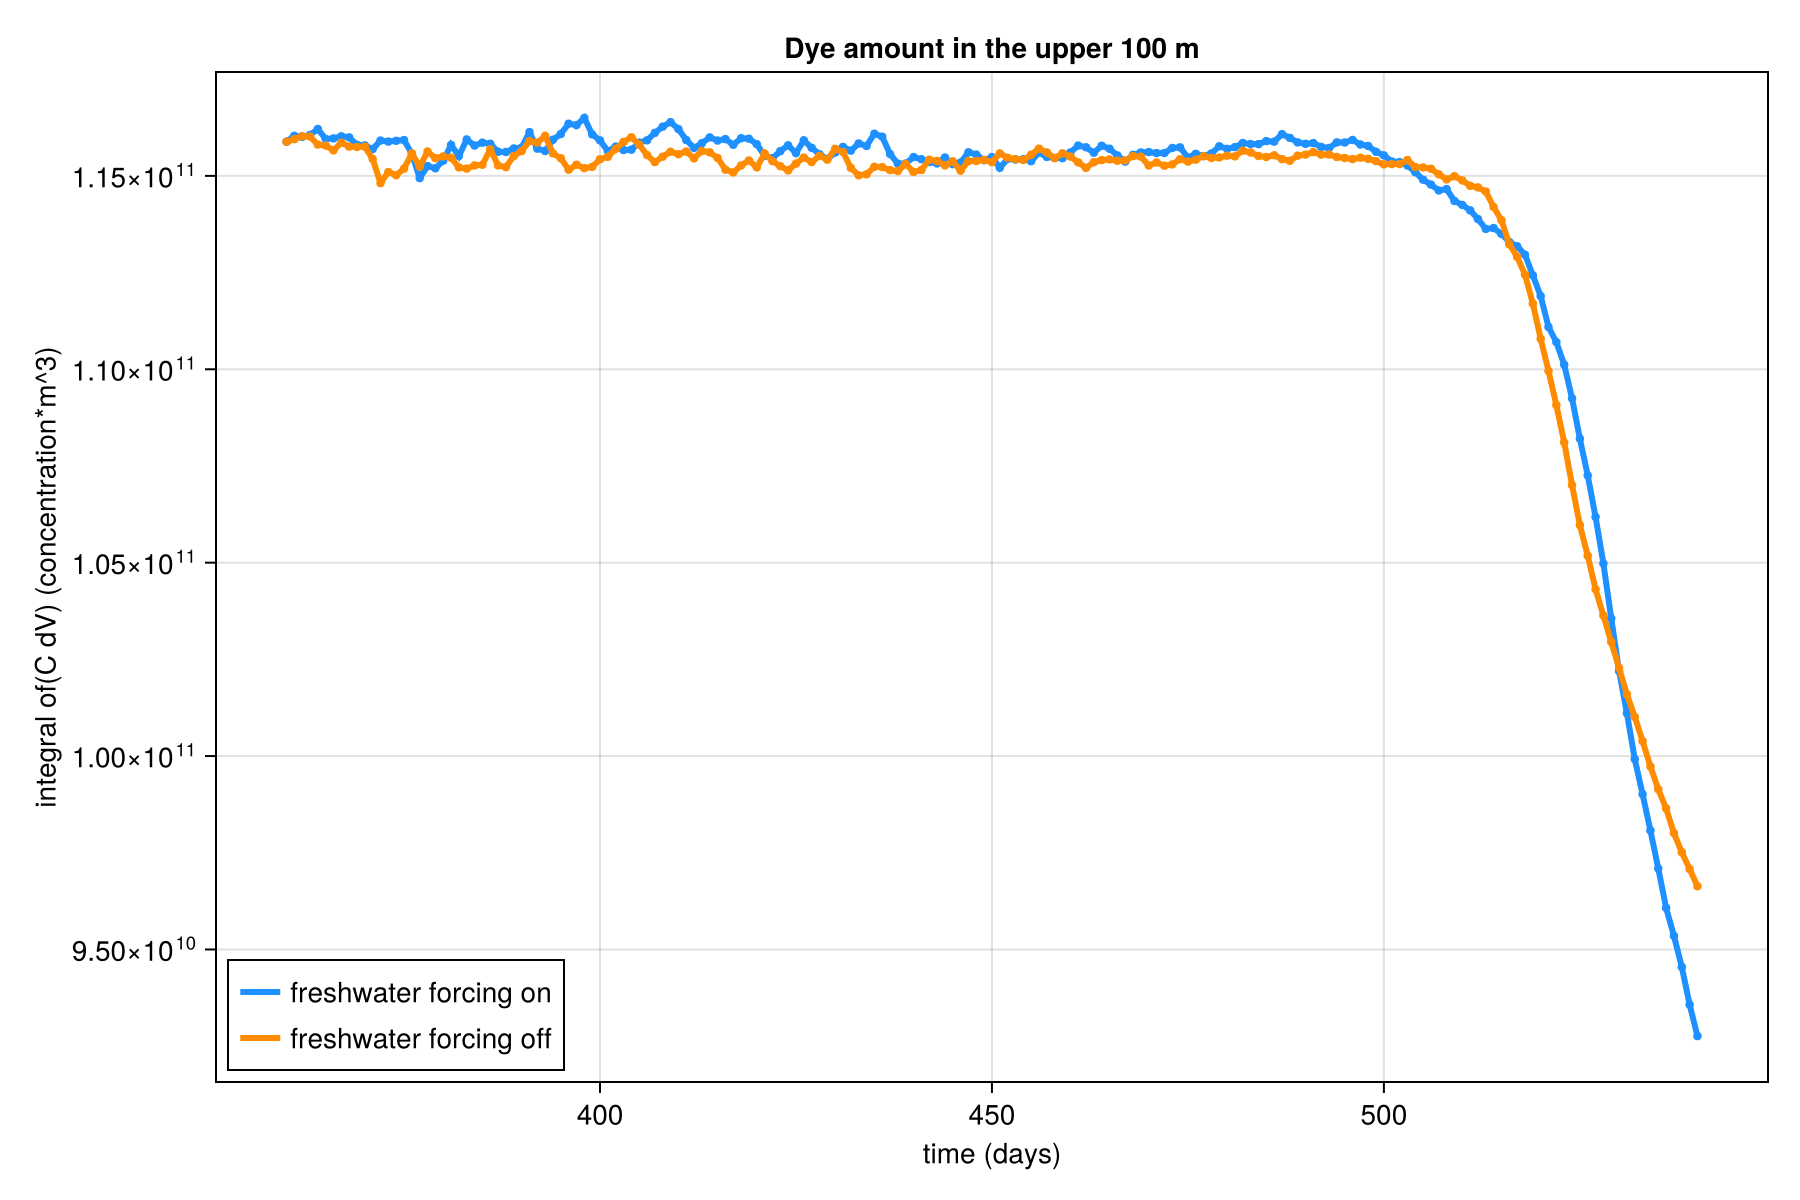

In [10]:
# compare init dye amounts + scale the difference 
initial_difference = upper_100m_amount_on[1] - upper_100m_amount_off[1]

# scale the difference so the comparison does not depend on tracer magnitude
initial_scale = max(
    abs(upper_100m_amount_on[1]),
    abs(upper_100m_amount_off[1]),
    eps(Float64)
)

relative_initial_difference = abs(initial_difference) / initial_scale

# calculate the final fraction of the initial upper-ocean amount
fraction_remaining_on = upper_100m_amount_on[end] / upper_100m_amount_on[1]
fraction_remaining_off = upper_100m_amount_off[end] / upper_100m_amount_off[1]

# create the requested comparison figure
figure = Figure(size = (900, 600))

axis = Axis(
    figure[1, 1],
    title = "Dye amount in the upper 100 m",
    xlabel = "time (days)",
    ylabel = "integral of(C dV) (concentration*m^3)"
)

# plot the freshwater-on result
lines!(
    axis,
    times_days,
    upper_100m_amount_on;
    color = :dodgerblue,
    linewidth = 3,
    label = "freshwater forcing on"
)

# mark the individual freshwater-on outputs
scatter!(
    axis,
    times_days,
    upper_100m_amount_on;
    color = :dodgerblue,
    markersize = 6
)

# plot the freshwater-off control result
lines!(
    axis,
    times_days,
    upper_100m_amount_off;
    color = :darkorange,
    linewidth = 3,
    label = "freshwater forcing off"
)

# mark the individual freshwater-off outputs
scatter!(
    axis,
    times_days,
    upper_100m_amount_off;
    color = :darkorange,
    markersize = 6
)

# identify the two simulations
axislegend(axis; position = :lb)

# make sure the destination directory exists
mkpath("figures")

# use the final saved day in the output filename
final_day = round(Int, times_days[end])

# save the completed figure
save(
    "figures/amazon_upper_100m_dye_inventory_day$(final_day).png",
    figure
)

# display the result in the notebook
figure